* Here we covered 
*1) chi2.
*2) Feature Importance.
*3) Correlation.
*4) Mutual informataion classification
*5) Lasso

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
mobile = pd.read_csv('mobile_dataset.csv')

In [3]:
mobile.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
mobile.shape

(2000, 21)

In [5]:
mobile.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [6]:
mobile.columns.unique()

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [7]:
X = mobile.drop('price_range',axis = 1)
y = mobile.price_range

In [8]:
X.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [9]:
y.head()

0    1
1    2
2    2
3    2
4    1
Name: price_range, dtype: int64

# chi2

In [10]:

from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest

In [11]:
uni_analysis = SelectKBest(chi2, k =10)
uni = uni_analysis.fit(X,y)


In [12]:
uni.get_support()

array([ True, False, False, False,  True, False,  True, False,  True,
       False, False,  True,  True,  True,  True,  True,  True, False,
       False, False])

In [13]:
uni.scores_

array([1.41298666e+04, 7.23232323e-01, 6.48365906e-01, 6.31010795e-01,
       1.01351665e+01, 1.52157239e+00, 8.98391244e+01, 7.45819631e-01,
       9.59728626e+01, 9.09755558e+00, 9.18605355e+00, 1.73635695e+04,
       9.81058675e+03, 9.31267519e+05, 9.61487832e+00, 1.64803191e+01,
       1.32364000e+01, 3.27642810e-01, 1.92842942e+00, 4.22090730e-01])

In [14]:
unidf = pd.DataFrame({'scores':uni.scores_}, index = X.columns)

In [15]:
unidf

,scores
battery_power,14129.866576
blue,0.723232
clock_speed,0.648366
dual_sim,0.631011
fc,10.135166
four_g,1.521572
int_memory,89.839124
m_dep,0.745820
mobile_wt,95.972863
n_cores,9.097556


In [16]:
unidf.nlargest(10,'scores')

,scores
ram,931267.519053
px_height,17363.569536
battery_power,14129.866576
px_width,9810.586750
mobile_wt,95.972863
int_memory,89.839124
sc_w,16.480319
talk_time,13.236400
fc,10.135166
sc_h,9.614878


# Feature Importance
* The more the higher importance we can take value.

In [17]:
from sklearn.ensemble import ExtraTreesClassifier
# we can use ExtraTreesRegressor for regression problems. 

In [18]:
dtc = ExtraTreesClassifier()

In [19]:
dtc.fit(X,y)

ExtraTreesClassifier()

In [20]:
a =dtc.feature_importances_

In [21]:
dtcdf = pd.DataFrame({'scores':a}, index = X.columns)

In [22]:
dtcdf

,scores
battery_power,0.063102
blue,0.019128
clock_speed,0.032888
dual_sim,0.019490
fc,0.032102
four_g,0.018129
int_memory,0.035079
m_dep,0.033234
mobile_wt,0.035814
n_cores,0.033438


In [23]:
dtcdf.nlargest(10,'scores')

,scores
ram,0.394805
battery_power,0.063102
px_height,0.047986
px_width,0.047428
mobile_wt,0.035814
int_memory,0.035079
talk_time,0.034714
sc_w,0.033868
n_cores,0.033438
m_dep,0.033234


<AxesSubplot:>

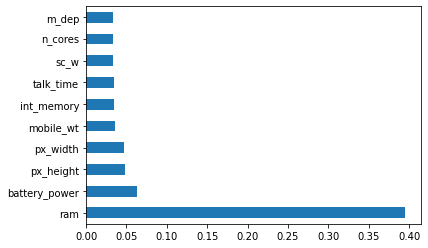

In [24]:
show = pd.Series(a,index = X.columns)
show.nlargest(10).plot(kind = 'barh')

# Correlation

In [25]:
X.corr()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,0.031441,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,-0.009952,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,-0.005245,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,-0.017143,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,0.644595,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,-0.005598,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,-0.033273,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,0.026282,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,0.018844,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,-0.001193,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964


<AxesSubplot:>

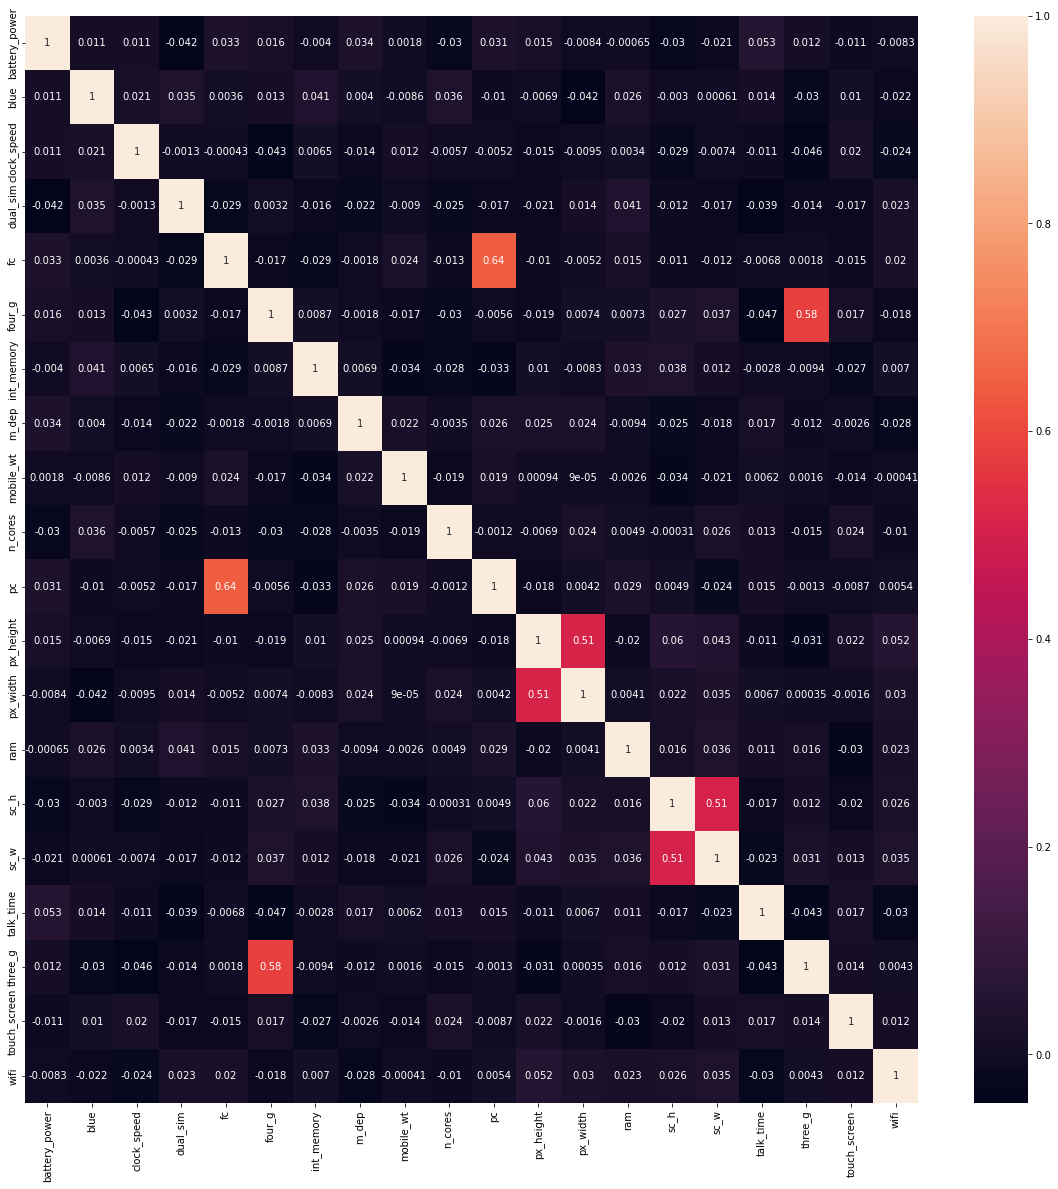

In [26]:
plt.figure(figsize = (20,20))
sns.heatmap(X.corr(),annot = True)


In [27]:
threshold = 0.8

In [28]:
def correlation(data, threshold):
    coll_cor = set()
    corr_matrix = data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                coll_cor.add(colname)
    return coll_cor

In [29]:
correlation(X,0.5)

{'pc', 'px_width', 'sc_w', 'three_g'}

# Mutual Info Classif
* It's is also called as information gain.


In [30]:
from sklearn.feature_selection import mutual_info_classif

In [31]:
mutual = mutual_info_classif(X,y)

In [32]:
mutual

array([3.29503436e-02, 0.00000000e+00, 1.00232887e-02, 2.08666484e-02,
       3.06502014e-04, 6.25444568e-03, 0.00000000e+00, 5.41773222e-03,
       1.58542228e-02, 2.21202413e-02, 0.00000000e+00, 2.86477289e-02,
       2.70122219e-02, 8.50699066e-01, 0.00000000e+00, 5.14174082e-03,
       8.54541450e-04, 1.17847395e-02, 5.73108267e-03, 3.33764817e-02])

In [33]:
mutual = pd.Series(mutual)
mutual.index = X.columns


In [34]:
mutual.sort_values(ascending = False)
# The higher the mutual info we can get the value

ram              0.850699
wifi             0.033376
battery_power    0.032950
px_height        0.028648
px_width         0.027012
n_cores          0.022120
dual_sim         0.020867
mobile_wt        0.015854
three_g          0.011785
clock_speed      0.010023
four_g           0.006254
touch_screen     0.005731
m_dep            0.005418
sc_w             0.005142
talk_time        0.000855
fc               0.000307
int_memory       0.000000
blue             0.000000
sc_h             0.000000
pc               0.000000
dtype: float64

In [35]:
from sklearn.feature_selection import SelectKBest

In [36]:
mut = SelectKBest(mutual_info_classif,k = 10)
mut.fit(X,y)

SelectKBest(score_func=<function mutual_info_classif at 0x0000021D65968948>)

In [37]:
mut.get_support()

array([ True,  True, False, False,  True, False,  True, False, False,
       False, False,  True,  True,  True,  True, False,  True,  True,
       False, False])

In [38]:
mut.scores_

array([0.02789987, 0.0127979 , 0.        , 0.0009106 , 0.03509715,
       0.00855335, 0.0258312 , 0.00128091, 0.01120565, 0.        ,
       0.        , 0.02669488, 0.0222666 , 0.84988513, 0.01133172,
       0.00590623, 0.0234268 , 0.02779739, 0.        , 0.        ])

# Lasso

In [39]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [41]:
model=SelectFromModel(Lasso(alpha=0.005,random_state=0))
model.fit(X_train, y_train)

SelectFromModel(estimator=Lasso(alpha=0.005, random_state=0))

In [42]:
selected_featrues = X_train.columns[(model.get_support())]

In [45]:
selected_featrues # we can take this for model purpose

Index(['battery_power', 'clock_speed', 'dual_sim', 'fc', 'int_memory',
       'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h',
       'sc_w', 'talk_time', 'three_g'],
      dtype='object')